# Chapter 4 — Evaluation and Results

This chapter presents a rigorous and reproducible evaluation framework for multi-horizon UK inflation (CPI YoY) forecasting. The evaluation compares three model families under identical experimental conditions (temporal splits and forecast horizons), enabling fair comparison across classical time-series methods, machine learning baselines, and the proposed hybrid approach.

## Evaluation Framework

### Models under evaluation

**1) Statistical baseline: ARIMA.**  
Autoregressive Integrated Moving Average (ARIMA) serves as a classical univariate benchmark. It is widely used for macroeconomic time series because it provides a transparent, parametric baseline that captures autocorrelation and trend/seasonality components through differencing and AR/MA terms. In this dissertation, ARIMA is treated as a *non-learning* baseline during evaluation: all ARIMA forecasts are loaded from previously generated artifacts and are **not re-tuned** at this stage.

**2) Machine learning baseline: Random Forest (multi-output).**  
Random Forest (RF) provides a strong, non-linear baseline that can exploit engineered macroeconomic and lagged features without requiring strict stationarity assumptions. The RF baseline in this project is trained in a multi-output configuration to forecast multiple horizons simultaneously. As with ARIMA, RF is **not re-tuned** in this notebook; we evaluate saved predictions produced earlier in the workflow.

**3) Proposed model: Hybrid LSTM–XGBoost (single final architecture).**  
The hybrid LSTM–XGBoost model is the proposed contribution. It combines sequence modelling (LSTM) to learn temporal representations from lagged input windows with a gradient-boosted tree model (XGBoost) to map learned representations (and/or engineered features) to horizon-specific forecasts. The model is evaluated as a single final architecture using saved predictions for each forecast horizon.

### Horizon-wise evaluation and temporal splits

**Forecast horizons.** All models are evaluated on the same horizons: **t+1, t+3, and t+5** months ahead. Horizon-wise evaluation is required because forecasting error typically increases with lead time due to compounding uncertainty; a single aggregated score would mask this deterioration and potentially misrepresent practical performance.

**Temporal train/validation/test splits.** The evaluation respects the time order of macroeconomic data. All reported results are computed on the **test period** forecasts generated earlier using an identical temporal split policy across models. No random shuffling is used, and no information from the test set is permitted to influence model training or hyperparameter selection.

### Metrics and artifact-based evaluation

To ensure consistency and comparability, performance is reported using standard point-forecast metrics computed on the test set:

- **MAE (Mean Absolute Error):** $\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|$  
- **RMSE (Root Mean Squared Error):** $\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$  
- **$R^2$ (Coefficient of Determination):** measures explained variance relative to a constant mean predictor.

In addition to numerical summaries, the evaluation uses **visual diagnostics** to assess temporal tracking (alignment with turning points) and volatility behaviour across models.

### Reproducibility: upstream artifact provenance checks

This notebook assumes forecasts were produced earlier and saved to disk as artifacts. Before computing any evaluation metrics, we **verify that the required artifacts exist and record their modification timestamps**. These checks are organised to mirror the upstream workflow:

- **Notebook 03 (Baselines):** ARIMA artifacts
- **Notebook 04 (ML Models):** Random Forest artifacts
- **Notebook 05 (Hybrid Method):** Hybrid LSTM–XGBoost artifacts

This step improves reproducibility by making the evaluation dependent on explicit, versioned files rather than implicit in-memory state.

In [1]:
# Baseline model (RF) — MAE / RMSE / R² for each split and horizon
from pathlib import Path
import pandas as pd

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "results").exists() and (p / "src").exists():
            return p
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
baseline_metrics_path = PROJECT_ROOT / "artifacts" / "rf_baseline_metrics.csv"
if not baseline_metrics_path.exists():
    raise FileNotFoundError(f"Missing baseline metrics: {baseline_metrics_path}")

df_baseline = pd.read_csv(baseline_metrics_path)

split_order = ["train", "validation", "test"]
horizon_order = ["cpi_t1", "cpi_t3", "cpi_t5"]
df_baseline["split"] = pd.Categorical(df_baseline["split"], categories=split_order, ordered=True)
df_baseline["horizon"] = pd.Categorical(df_baseline["horizon"], categories=horizon_order, ordered=True)

# Long table (one row per split-horizon)
baseline_long = df_baseline.sort_values(["split", "horizon"])[["split", "horizon", "mae", "rmse", "r2"]].round(3)
display(baseline_long)

# Wide table (splits as rows, horizons as columns)
baseline_wide = (
    df_baseline.sort_values(["split", "horizon"])
    .pivot(index="split", columns="horizon", values=["mae", "rmse", "r2"])
    .round(3)
)
display(baseline_wide)

,split,horizon,mae,rmse,r2
0,train,cpi_t1,0.103,0.140,0.984
1,train,cpi_t3,0.134,0.192,0.971
2,train,cpi_t5,0.147,0.218,0.962
3,validation,cpi_t1,0.337,0.462,0.853
4,validation,cpi_t3,0.724,1.062,0.512
5,validation,cpi_t5,1.312,1.822,0.213
6,test,cpi_t1,2.724,3.713,-0.274
7,test,cpi_t3,3.069,4.148,-0.545
8,test,cpi_t5,3.044,4.116,-0.571


mae                 rmse                   r2              
horizon    cpi_t1 cpi_t3 cpi_t5 cpi_t1 cpi_t3 cpi_t5 cpi_t1 cpi_t3 cpi_t5
split                                                                    
train       0.103  0.134  0.147  0.140  0.192  0.218  0.984  0.971  0.962
validation  0.337  0.724  1.312  0.462  1.062  1.822  0.853  0.512  0.213
test        2.724  3.069  3.044  3.713  4.148  4.116 -0.274 -0.545 -0.571

In [2]:
# Artifact check — Notebook 03 (Baselines: ARIMA)
from __future__ import annotations

from pathlib import Path
from datetime import datetime
import pandas as pd

def _fmt_mtime(path: Path) -> str:
    ts = datetime.fromtimestamp(path.stat().st_mtime)
    return ts.strftime("%Y-%m-%d %H:%M:%S")

def find_project_root(start: Path) -> Path:
    """Find repo root so relative paths work when notebook runs from /notebooks."""
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "results").exists() and (p / "src").exists():
            return p
    return start

def artifact_status(paths: list[Path], label: str, upstream_notebook: Path | None = None) -> pd.DataFrame:
    nb_exists = bool(upstream_notebook and upstream_notebook.exists())
    nb_mtime = upstream_notebook.stat().st_mtime if nb_exists else None
    nb_mtime_str = _fmt_mtime(upstream_notebook) if nb_exists else None

    rows: list[dict] = []
    for p in paths:
        exists = p.exists()
        art_mtime = p.stat().st_mtime if exists else None
        rows.append(
            {
                "group": label,
                "path": str(p),
                "exists": bool(exists),
                "modified": _fmt_mtime(p) if exists else None,
                "size_kb": round(p.stat().st_size / 1024, 1) if exists else None,
                "upstream_notebook": str(upstream_notebook) if upstream_notebook else None,
                "upstream_notebook_modified": nb_mtime_str,
                "artifact_newer_than_upstream": (art_mtime >= nb_mtime) if (exists and nb_exists) else None,
            }
        )
    df = pd.DataFrame(rows)
    return df

PROJECT_ROOT = find_project_root(Path.cwd())
print("Project root:", PROJECT_ROOT)

BASELINE_DIR = PROJECT_ROOT / "results" / "baselines"
NOTEBOOK_03 = PROJECT_ROOT / "notebooks" / "03_baseline_models.ipynb"

arima_artifacts = [
    BASELINE_DIR / "arima_test_dates.npy",
    BASELINE_DIR / "arima_test_actual.npy",
    BASELINE_DIR / "arima_test_forecast.npy",
    BASELINE_DIR / "arima_test_forecast.csv",
]

df03 = artifact_status(arima_artifacts, label="Notebook 03 — ARIMA", upstream_notebook=NOTEBOOK_03)
display(df03)

missing = df03.loc[~df03["exists"], "path"].tolist()
if missing:
    raise FileNotFoundError("Missing ARIMA artifacts:\n" + "\n".join(missing))

print("All Notebook 03 ARIMA artifacts found.")
if NOTEBOOK_03.exists():
    print("Upstream notebook last modified:", _fmt_mtime(NOTEBOOK_03))
    stale = df03.loc[df03["artifact_newer_than_upstream"] == False, "path"].tolist()  # noqa: E712
    if stale:
        print("WARNING: Some artifacts are older than the upstream notebook (not necessarily wrong, but worth re-running upstream if unexpected):")
        for p in stale:
            print(" -", p)

Project root: C:\Users\reset\OneDrive - UWE Bristol\Master_project\UK-inflation-forecasting-XAI


,group,path,exists,modified,size_kb,upstream_notebook,upstream_notebook_modified,artifact_newer_than_upstream
0,Notebook 03 — ARIMA,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 17:13:25,0.4,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 05:00:30,True
1,Notebook 03 — ARIMA,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 17:13:25,0.4,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 05:00:30,True
2,Notebook 03 — ARIMA,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 17:13:25,0.4,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 05:00:30,True
3,Notebook 03 — ARIMA,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 17:13:25,1.3,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 05:00:30,True


All Notebook 03 ARIMA artifacts found.
Upstream notebook last modified: 2026-01-03 05:00:30


In [3]:
# Artifact check — Notebook 04 (ML Models: Random Forest)
RF_DIR = PROJECT_ROOT / "results" / "baselines" / "rf"
NOTEBOOK_04 = PROJECT_ROOT / "notebooks" / "04_ml_models.ipynb"

rf_artifacts = [
    RF_DIR / "rf_test_predictions.csv",
    RF_DIR / "rf_test_actual.npy",
    RF_DIR / "rf_test_dates.npy",
    RF_DIR / "rf_models.joblib",
    RF_DIR / "rf_params.json",
    RF_DIR / "feature_cols.json",
    RF_DIR / "target_cols.json",
    RF_DIR / "split_config.json",
]

df04 = artifact_status(rf_artifacts, label="Notebook 04 — Random Forest", upstream_notebook=NOTEBOOK_04)
display(df04)

missing = df04.loc[~df04["exists"], "path"].tolist()
if missing:
    raise FileNotFoundError("Missing Random Forest artifacts:\n" + "\n".join(missing))

print("All Notebook 04 Random Forest artifacts found.")
if NOTEBOOK_04.exists():
    print("Upstream notebook last modified:", _fmt_mtime(NOTEBOOK_04))

,group,path,exists,modified,size_kb,upstream_notebook,upstream_notebook_modified,artifact_newer_than_upstream
0,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,2.5,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False
1,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,1.0,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False
2,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,0.4,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False
3,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,24392.8,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False
4,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,0.1,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False
5,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,0.2,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False
6,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,0.0,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False
7,Notebook 04 — Random Forest,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-03 02:37:25,0.1,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:49:53,False


All Notebook 04 Random Forest artifacts found.
Upstream notebook last modified: 2026-01-03 07:49:53


In [4]:
# Artifact check — Notebook 05 (Hybrid Method: LSTM–XGBoost)
HYBRID_DIR = PROJECT_ROOT / "results" / "hybrid"
NOTEBOOK_05 = PROJECT_ROOT / "notebooks" / "05_Hypertune_hybrid_method.ipynb"

hybrid_artifacts = [
    HYBRID_DIR / "xgb_cpi_t1_predictions.csv",
    HYBRID_DIR / "xgb_cpi_t3_predictions.csv",
    HYBRID_DIR / "xgb_cpi_t5_predictions.csv",
    HYBRID_DIR / "xgb_model_config.json",
    HYBRID_DIR / "xgb_summary.json",
    HYBRID_DIR / "xgb_feature_names.json",
    HYBRID_DIR / "feature_names.json",
]

df05 = artifact_status(hybrid_artifacts, label="Notebook 05 — Hybrid", upstream_notebook=NOTEBOOK_05)
display(df05)

missing = df05.loc[~df05["exists"], "path"].tolist()
if missing:
    raise FileNotFoundError("Missing hybrid artifacts:\n" + "\n".join(missing))

print("All Notebook 05 Hybrid artifacts found.")
if NOTEBOOK_05.exists():
    print("Upstream notebook last modified:", _fmt_mtime(NOTEBOOK_05))

,group,path,exists,modified,size_kb,upstream_notebook,upstream_notebook_modified,artifact_newer_than_upstream
0,Notebook 05 — Hybrid,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 14:52:08,0.9,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:46:09,True
1,Notebook 05 — Hybrid,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 14:52:08,0.9,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:46:09,True
2,Notebook 05 — Hybrid,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 14:52:08,0.9,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:46:09,True
3,Notebook 05 — Hybrid,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 14:52:08,0.9,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:46:09,True
4,Notebook 05 — Hybrid,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 14:52:08,0.2,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:46:09,True
5,Notebook 05 — Hybrid,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2026-01-05 14:52:08,0.3,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:46:09,True
6,Notebook 05 — Hybrid,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,True,2025-12-31 01:11:01,0.2,C:\Users\reset\OneDrive - UWE Bristol\Master_p...,2026-01-03 07:46:09,False


All Notebook 05 Hybrid artifacts found.
Upstream notebook last modified: 2026-01-03 07:46:09


## Random Forest baseline — test-set diagnostics
This section reports Random Forest (RF) **test-set** performance by horizon and visual diagnostics:
- A horizon-wise metrics table (MAE, RMSE, $R^2$)
- Actual vs predicted scatter plots (with a $y=x$ reference)
- Time series plots comparing actual and predicted CPI YoY over the test period

,MAE,RMSE,R2,n
horizon,,,,
t+1,2.424,3.327,-0.023,38
t+3,2.330,3.031,0.175,38
t+5,2.369,3.045,0.140,38


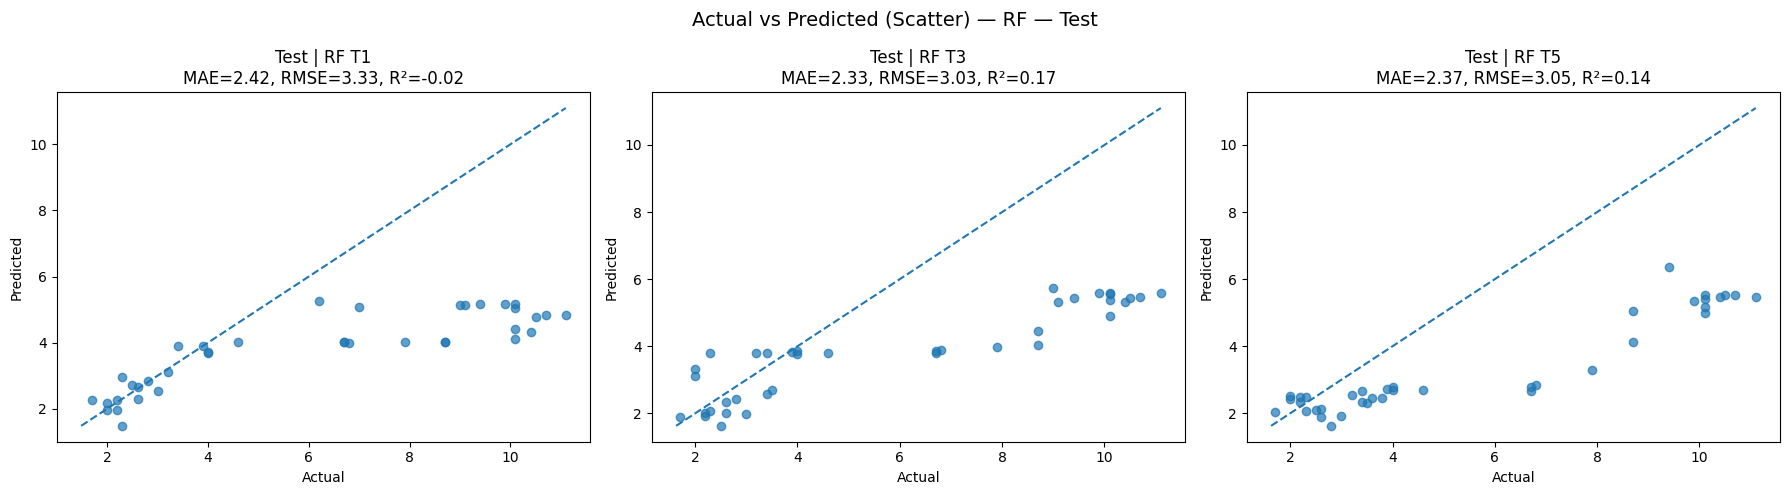

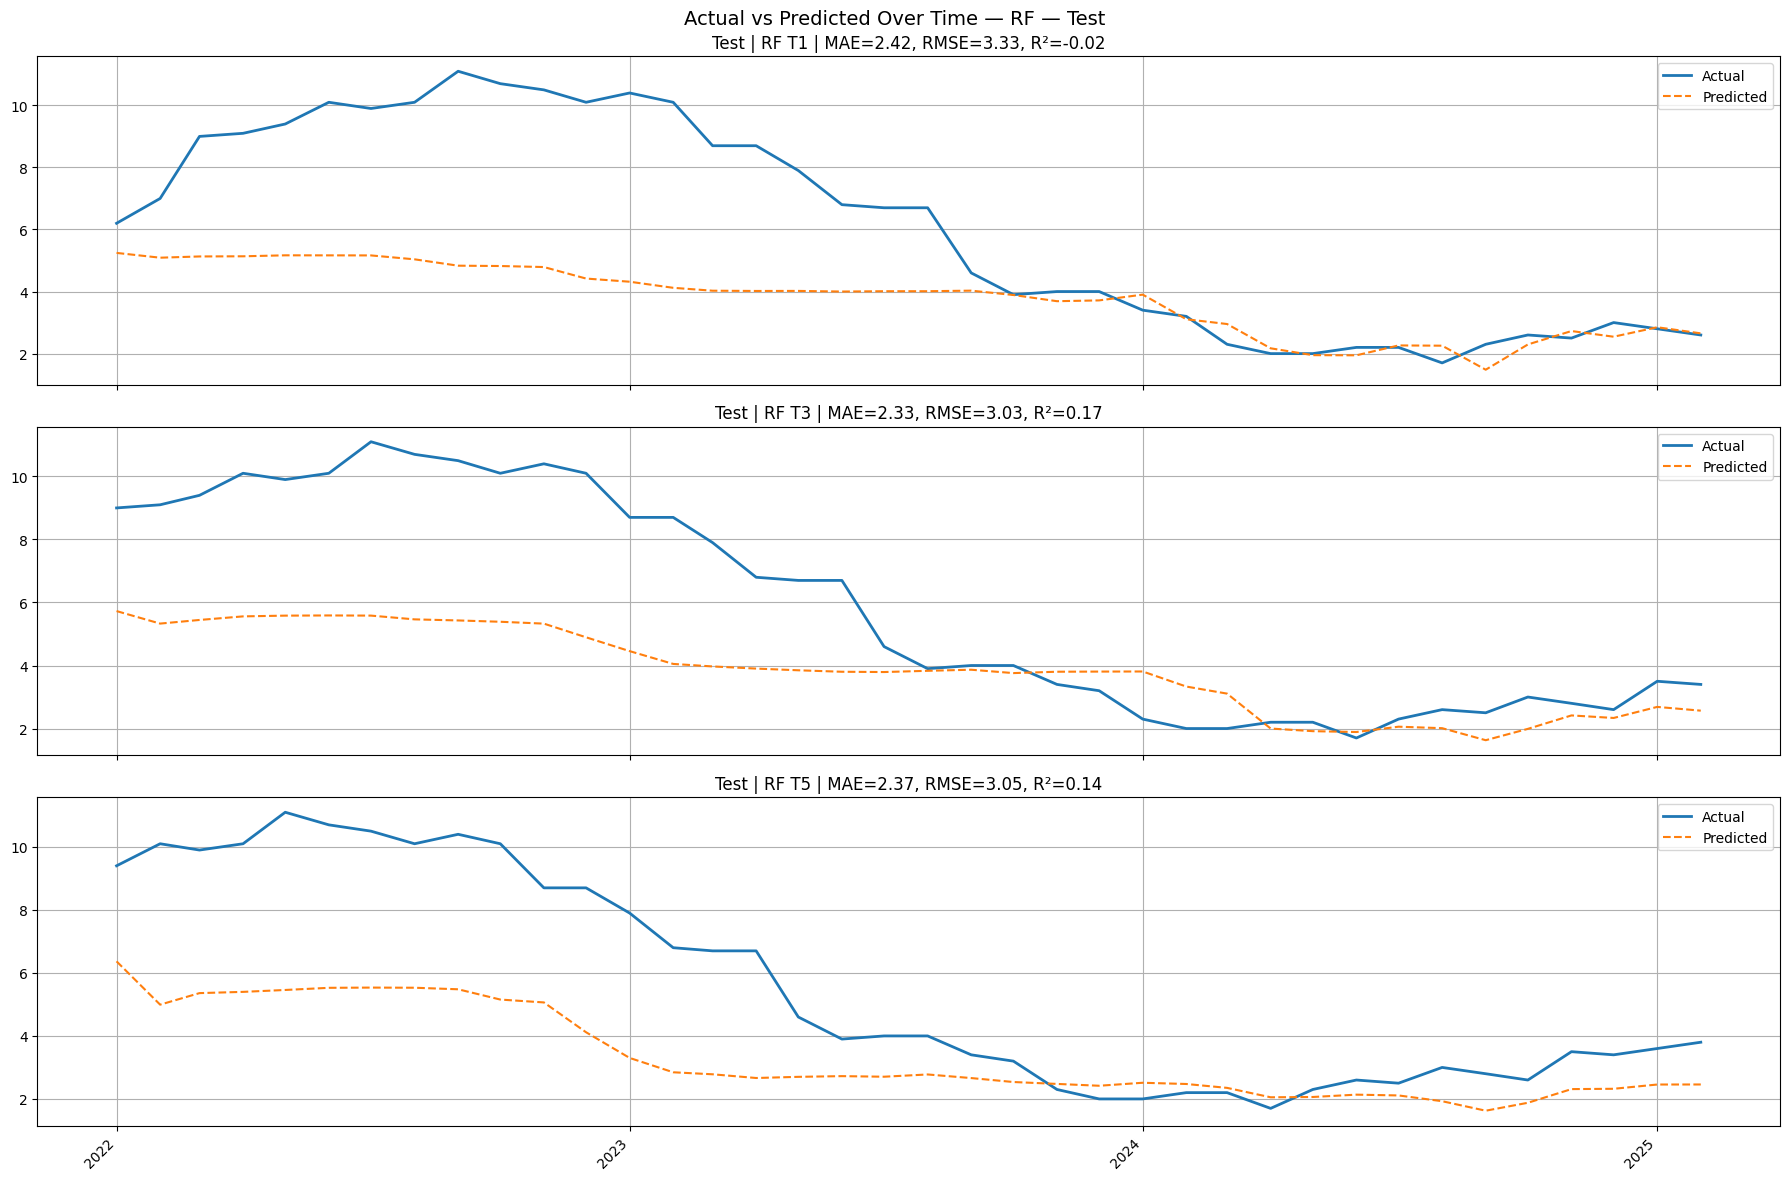

In [5]:
# RF baseline: metrics table + scatter + actual-vs-predicted plots (test set)
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "results").exists() and (p / "src").exists():
            return p
    return start

def eval_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }

def prepare_eval_df(preds_df: pd.DataFrame, y_df: pd.DataFrame) -> pd.DataFrame:
    df = preds_df.copy()
    df["actual_t1"] = y_df["cpi_t1"].values
    df["actual_t3"] = y_df["cpi_t3"].values
    df["actual_t5"] = y_df["cpi_t5"].values
    # Keep structure consistent with other models (drop NaNs if any)
    return df.dropna().reset_index(drop=True)

def plot_scatter_and_lines(preds_df: pd.DataFrame, y_df: pd.DataFrame, split_name: str, pred_prefix: str = "rf_pred"):
    horizons = ["t1", "t3", "t5"]
    df = prepare_eval_df(preds_df, y_df)

    # ---------------------------
    # FIGURE 1: Scatter (Actual vs Predicted)
    # ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, h in zip(axes, horizons):
        y_true = df[f"actual_{h}"]
        y_pred = df[f"{pred_prefix}_{h}"]
        m = eval_metrics(y_true, y_pred)

        ax.scatter(y_true, y_pred, alpha=0.7)
        lo = min(y_true.min(), y_pred.min())
        hi = max(y_true.max(), y_pred.max())
        ax.plot([lo, hi], [lo, hi], linestyle="--")

        ax.set_title(
            f"{split_name} | RF {h.upper()}\n"
            f"MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, R²={m['R2']:.2f}"
        )
        ax.set_xlabel("Actual")
        ax.set_ylabel("Predicted")

    plt.suptitle(f"Actual vs Predicted (Scatter) — RF — {split_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

    # -----------------------------------
    # FIGURE 2: Line (Actual vs Predicted)
    # -----------------------------------
    fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
    for ax, h in zip(axes, horizons):
        dates = pd.to_datetime(df["date"])
        y_true = df[f"actual_{h}"]
        y_pred = df[f"{pred_prefix}_{h}"]
        m = eval_metrics(y_true, y_pred)

        ax.plot(dates, y_true, label="Actual", linewidth=2)
        ax.plot(dates, y_pred, label="Predicted", linestyle="--")
        ax.set_title(
            f"{split_name} | RF {h.upper()} | "
            f"MAE={m['MAE']:.2f}, RMSE={m['RMSE']:.2f}, R²={m['R2']:.2f}"
        )
        ax.grid(True)
        ax.legend()

    # Format x-axis: show one tick per year to reduce clutter
    for ax in axes:
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
    plt.suptitle(f"Actual vs Predicted Over Time — RF — {split_name}", fontsize=14)
    plt.tight_layout()
    plt.show()

PROJECT_ROOT = find_project_root(Path.cwd())
rf_dir = PROJECT_ROOT / "results" / "baselines" / "rf"

pred_path = rf_dir / "rf_test_predictions.csv"
actual_path = rf_dir / "rf_test_actual.npy"
target_cols_path = rf_dir / "target_cols.json"

for p in [pred_path, actual_path, target_cols_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing RF artifact: {p}")

preds_df = pd.read_csv(pred_path)
preds_df["date"] = pd.to_datetime(preds_df["date"], errors="raise")
preds_df = preds_df.sort_values("date").reset_index(drop=True)

# Ensure prediction columns match the expected names used by the plotting function
expected_pred_cols = ["rf_pred_t1", "rf_pred_t3", "rf_pred_t5"]
missing_pred_cols = [c for c in expected_pred_cols if c not in preds_df.columns]
if missing_pred_cols:
    raise KeyError(f"Missing RF prediction columns: {missing_pred_cols}")

with open(target_cols_path, "r", encoding="utf-8") as f:
    target_cols = json.load(f)  # e.g. ["cpi_t1", "cpi_t3", "cpi_t5"]

y_true = np.load(actual_path)
if y_true.ndim == 1:
    if y_true.size % len(target_cols) != 0:
        raise ValueError("rf_test_actual.npy cannot be reshaped to match target_cols.")
    y_true = y_true.reshape(-1, len(target_cols))

if y_true.shape[0] != len(preds_df):
    raise ValueError(f"Length mismatch: predictions have {len(preds_df)} rows, actuals have {y_true.shape[0]} rows.")

y_df = pd.DataFrame(y_true, columns=target_cols)

# --- Metrics table (test set) ---
rows = []
for h, actual_col, pred_col in [("t+1", "cpi_t1", "rf_pred_t1"), ("t+3", "cpi_t3", "rf_pred_t3"), ("t+5", "cpi_t5", "rf_pred_t5")]:
    m = eval_metrics(y_df[actual_col], preds_df[pred_col])
    rows.append({"horizon": h, **m, "n": len(y_df)})

rf_test_metrics = pd.DataFrame(rows).set_index("horizon").round(3)
display(rf_test_metrics)

# --- Plots (same style as your LSTM helper) ---
plot_scatter_and_lines(preds_df, y_df, split_name="Test", pred_prefix="rf_pred")

## Hybrid model (LSTM–XGBoost) — test-set diagnostics and comparison vs RF

This section evaluates the **Hybrid LSTM–XGBoost** model on the **test set** using the saved artifacts from Notebook 05. It then provides a direct comparison against the Random Forest baseline (RF) under the same horizons (t+1, t+3, t+5).

Reported outputs:
- A table of **MAE / RMSE / R²** for **RF vs Hybrid** per horizon (computed on common dates)
- Line plots of **Actual vs RF vs Hybrid** for each horizon (clear, high-contrast styling)

,n,RF_MAE,RF_RMSE,RF_R2,Hybrid_MAE,Hybrid_RMSE,Hybrid_R2
horizon,,,,,,,
t+1,35,2.439,3.386,0.000,2.772,3.781,-0.246
t+3,35,2.215,2.969,0.205,2.798,3.907,-0.376
t+5,35,2.210,2.911,0.159,2.718,3.812,-0.442


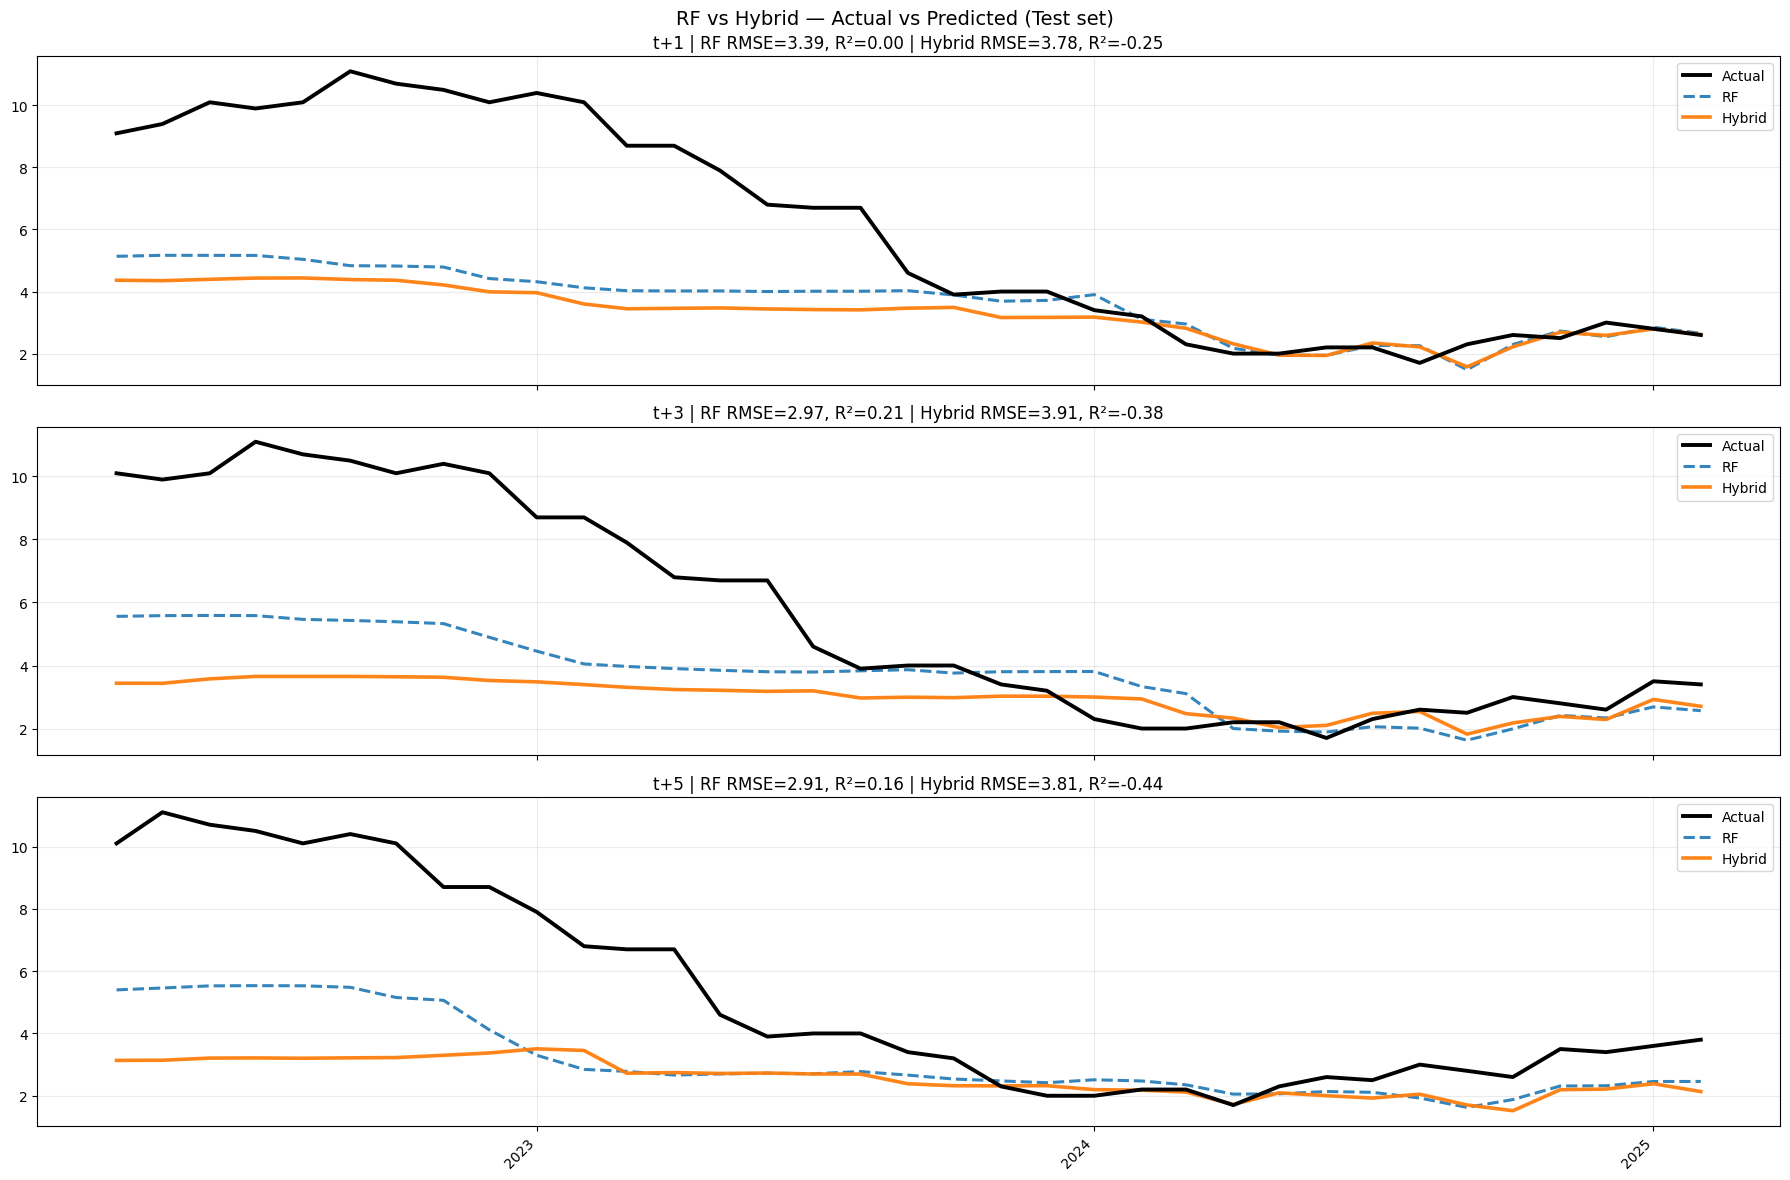

In [6]:
# RF vs Hybrid (LSTM–XGBoost): metrics table + comparison line plots (test set)
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / "results").exists() and (p / "src").exists():
            return p
    return start

def eval_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": float(r2_score(y_true, y_pred)),
    }

PROJECT_ROOT = find_project_root(Path.cwd())

# -----------------------------
# Load RF test artifacts
# -----------------------------
rf_dir = PROJECT_ROOT / "results" / "baselines" / "rf"
rf_pred_path = rf_dir / "rf_test_predictions.csv"
rf_actual_path = rf_dir / "rf_test_actual.npy"
rf_target_cols_path = rf_dir / "target_cols.json"

for p in [rf_pred_path, rf_actual_path, rf_target_cols_path]:
    if not p.exists():
        raise FileNotFoundError(f"Missing RF artifact: {p}")

rf_preds = pd.read_csv(rf_pred_path)
rf_preds["date"] = pd.to_datetime(rf_preds["date"], errors="raise")
rf_preds = rf_preds.sort_values("date").reset_index(drop=True)

expected_rf_cols = ["rf_pred_t1", "rf_pred_t3", "rf_pred_t5"]
missing_rf_cols = [c for c in expected_rf_cols if c not in rf_preds.columns]
if missing_rf_cols:
    raise KeyError(f"Missing RF prediction columns: {missing_rf_cols}")

with open(rf_target_cols_path, "r", encoding="utf-8") as f:
    rf_target_cols = json.load(f)  # ["cpi_t1", "cpi_t3", "cpi_t5"]

y_true = np.load(rf_actual_path)
if y_true.ndim == 1:
    if y_true.size % len(rf_target_cols) != 0:
        raise ValueError("rf_test_actual.npy cannot be reshaped to match target_cols.")
    y_true = y_true.reshape(-1, len(rf_target_cols))

if y_true.shape[0] != len(rf_preds):
    raise ValueError(f"Length mismatch: RF predictions have {len(rf_preds)} rows, actuals have {y_true.shape[0]} rows.")

rf_actuals = pd.DataFrame(y_true, columns=rf_target_cols)
rf_actuals.insert(0, "date", rf_preds["date"].values)

# -----------------------------
# Load Hybrid test artifacts
# -----------------------------
hybrid_dir = PROJECT_ROOT / "results" / "hybrid"
hybrid_files = {
    "t1": hybrid_dir / "xgb_cpi_t1_predictions.csv",
    "t3": hybrid_dir / "xgb_cpi_t3_predictions.csv",
    "t5": hybrid_dir / "xgb_cpi_t5_predictions.csv",
}
for p in hybrid_files.values():
    if not p.exists():
        raise FileNotFoundError(f"Missing Hybrid artifact: {p}")

hybrid_preds_by_h = {}
for h, path in hybrid_files.items():
    dfh = pd.read_csv(path)
    # saved as: dates, actual, predicted
    if "dates" not in dfh.columns or "predicted" not in dfh.columns:
        raise KeyError(f"Expected columns ['dates','predicted'] in {path.name}, found {list(dfh.columns)}")
    dfh = dfh.rename(columns={"dates": "date", "predicted": f"hybrid_pred_{h}"})
    dfh["date"] = pd.to_datetime(dfh["date"], errors="coerce")
    dfh = dfh.dropna(subset=["date"]).sort_values("date")[["date", f"hybrid_pred_{h}"]]
    hybrid_preds_by_h[h] = dfh

# -----------------------------
# Build comparison table (common dates per horizon)
# -----------------------------
rows = []
horizon_specs = [
    ("t+1", "t1", "cpi_t1", "rf_pred_t1"),
    ("t+3", "t3", "cpi_t3", "rf_pred_t3"),
    ("t+5", "t5", "cpi_t5", "rf_pred_t5"),
 ]

for label, h, actual_col, rf_pred_col in horizon_specs:
    df_cmp = (
        rf_actuals[["date", actual_col]]
        .merge(rf_preds[["date", rf_pred_col]], on="date", how="inner")
        .merge(hybrid_preds_by_h[h], on="date", how="inner")
        .dropna()
        .reset_index(drop=True)
    )
    y = df_cmp[actual_col]
    m_rf = eval_metrics(y, df_cmp[rf_pred_col])
    m_hy = eval_metrics(y, df_cmp[f"hybrid_pred_{h}"])
    rows.append({
        "horizon": label,
        "n": int(len(df_cmp)),
        "RF_MAE": m_rf["MAE"],
        "RF_RMSE": m_rf["RMSE"],
        "RF_R2": m_rf["R2"],
        "Hybrid_MAE": m_hy["MAE"],
        "Hybrid_RMSE": m_hy["RMSE"],
        "Hybrid_R2": m_hy["R2"],
    })

rf_vs_hybrid = pd.DataFrame(rows).set_index("horizon").round(3)
display(rf_vs_hybrid)

# -----------------------------
# Line plots: Actual vs RF vs Hybrid (per horizon)
# -----------------------------
ACTUAL_STYLE = {"color": "black", "linewidth": 2.8, "alpha": 1.0, "zorder": 3}
RF_STYLE     = {"color": "tab:blue", "linewidth": 2.2, "alpha": 0.9, "linestyle": "--", "zorder": 2}
HY_STYLE     = {"color": "tab:orange", "linewidth": 2.6, "alpha": 0.95, "linestyle": "-", "zorder": 2}

fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
for ax, (label, h, actual_col, rf_pred_col) in zip(axes, horizon_specs):
    df_cmp = (
        rf_actuals[["date", actual_col]]
        .merge(rf_preds[["date", rf_pred_col]], on="date", how="inner")
        .merge(hybrid_preds_by_h[h], on="date", how="inner")
        .dropna()
        .reset_index(drop=True)
    )
    dates = pd.to_datetime(df_cmp["date"])
    y = df_cmp[actual_col]
    y_rf = df_cmp[rf_pred_col]
    y_hy = df_cmp[f"hybrid_pred_{h}"]
    m_rf = eval_metrics(y, y_rf)
    m_hy = eval_metrics(y, y_hy)

    ax.plot(dates, y, label="Actual", **ACTUAL_STYLE)
    ax.plot(dates, y_rf, label="RF", **RF_STYLE)
    ax.plot(dates, y_hy, label="Hybrid", **HY_STYLE)
    ax.set_title(
        f"{label} | RF RMSE={m_rf['RMSE']:.2f}, R²={m_rf['R2']:.2f} | "
        f"Hybrid RMSE={m_hy['RMSE']:.2f}, R²={m_hy['R2']:.2f}"
    )
    ax.grid(True, alpha=0.25)
    ax.legend()

for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=45, ha="right")
plt.suptitle("RF vs Hybrid — Actual vs Predicted (Test set)", fontsize=14)
plt.tight_layout()
plt.show()